# Segmented Analysis & Business Recommendation

## Objective

Aggregate conversion rates provide a high-level view of experiment performance.

However, users may respond differently depending on their level of ad exposure.

This analysis segments users into Low, Medium, and High exposure groups based on the number of advertisements seen and evaluates whether the advertising campaign consistently outperforms the PSA group across segments.

The goal is to determine whether the observed lift is broad-based or concentrated within specific user segments.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("../data/marketing_AB.csv")

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df = df.drop(columns=["unnamed:_0"])

print(df.shape)

(588101, 6)


In [3]:
df["exposure_bucket"] = pd.qcut(
    df["total_ads"],
    q=3,
    labels=[
        "Low Exposure",
        "Medium Exposure",
        "High Exposure"
    ]
)

df["exposure_bucket"].value_counts()

exposure_bucket
Low Exposure       201232
Medium Exposure    195410
High Exposure      191459
Name: count, dtype: int64

In [4]:
(
    df["exposure_bucket"]
      .value_counts()
      .sort_index()
)

exposure_bucket
Low Exposure       201232
Medium Exposure    195410
High Exposure      191459
Name: count, dtype: int64

In [5]:
segment_summary = (
    df.groupby(
        ["exposure_bucket","test_group"]
    )["converted"]
    .mean()
    .reset_index()
)

segment_summary["converted"] *= 100

segment_summary

/var/folders/dp/hqr1v30n75d_lqgk055tc6mw0000gn/T/ipykernel_62305/1998835692.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,exposure_bucket,test_group,converted
0,Low Exposure,ad,0.257891
1,Low Exposure,psa,0.303269
2,Medium Exposure,ad,0.774322
3,Medium Exposure,psa,0.787402
4,High Exposure,ad,6.786756
5,High Exposure,psa,4.366868


In [6]:
segment_pivot = (
    segment_summary.pivot(
        index="exposure_bucket",
        columns="test_group",
        values="converted"
    )
)

segment_pivot

test_group,ad,psa
exposure_bucket,,
Low Exposure,0.257891,0.303269
Medium Exposure,0.774322,0.787402
High Exposure,6.786756,4.366868


In [7]:
segment_pivot["lift_%"] = (
    (segment_pivot["ad"] - segment_pivot["psa"])
    / segment_pivot["psa"]
) * 100

segment_pivot.round(2)

test_group,ad,psa,lift_%
exposure_bucket,,,
Low Exposure,0.26,0.30,-14.96
Medium Exposure,0.77,0.79,-1.66
High Exposure,6.79,4.37,55.41


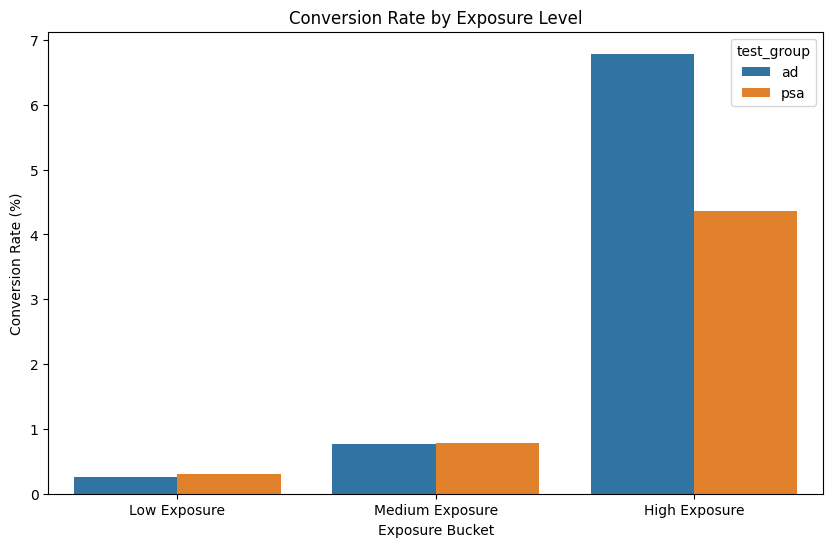

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_summary,
    x="exposure_bucket",
    y="converted",
    hue="test_group"
)

plt.title("Conversion Rate by Exposure Level")
plt.xlabel("Exposure Bucket")
plt.ylabel("Conversion Rate (%)")

plt.show()

# Business Recommendation

## Bottom Line Up Front (BLUF)

Roll out the advertising campaign.

The advertising treatment produced a statistically significant improvement in conversion rate relative to the PSA group, with a relative lift of approximately 43% and a p-value below 0.001.

---

## Supporting Evidence

- Advertising conversion rate: 2.56%
- PSA conversion rate: 1.79%
- Relative lift: approximately 43%
- Two-Proportion Z-Test: p < 0.001
- 95% Confidence Interval: +0.595 to +0.943 percentage points
- Statistical Power: 1.00

---

## Key Segment Insight

The strongest performance improvement occurs among users with high advertisement exposure.

While low- and medium-exposure users exhibit minimal differences between treatments, high-exposure users convert substantially more often under the advertising treatment.

This suggests that campaign effectiveness increases with repeated exposure.

---

## Caveats

- The observed effect size is statistically significant but relatively small in absolute terms.
- Results may not generalize beyond the exposure levels observed in this experiment.
- Additional testing should evaluate performance across different customer segments and campaign types.

---

## Next Steps

1. Deploy the advertising campaign to a larger audience.
2. Test optimal exposure frequency to determine the point of diminishing returns.
3. Conduct follow-up experiments on specific customer segments.
4. Measure long-term retention and revenue impact in addition to conversion.